# Unique Eccentricity Profiles

Unique eccentricity profiles refer to profiles where eccentricity is a unique function of semi-major axis, $e = e(a)$, which can also be written as $\psi(e, a) = \delta(e - e(a))$. Such eccentricity profiles are defined through the `UniqueEccentricity` class.

## Initialising the `UniqueEccentricity` Class

When initialising the eccentricity class, the user must firstly supply the `a_min` and `a_max` values, defining the range of semi-major axes.

In terms of the profile being used, there are two ways to initialise the class:

1. Using the **built-in power-law profile**, 
$$
e(a) = e_0 \left(\frac{a_{\min}}{a}\right)^{p}
$$

2. Providing a **custom function**,

$$
e(a) = e_0 \cdot e(a)_\text{custom}
$$

In both cases, the class automatically checks that the returned eccentricities lie within the physically valid range $0 \leq e(a) < 1$.

Unlike the `SigmaA` class, the eccentricity is **not truncated** outside of $[a_{\min}, a_{\max}]$. The `UniqueEccentricity` class is primarily a lightweight, object-oriented wrapper for storing and evaluating $e(a)$, and is designed for direct use with the `Kernel` class when computing the ASD.

### Built-In Eccentricity Profile

The class defaults to the built-in power-law profile, for which the user must define the scaling factor, `e0`, and the `power` argument.

In [1]:
# Import the class
from debrispy import UniqueEccentricity
import numpy as np

# Initialise
power_law = UniqueEccentricity(a_min=1, a_max=4, e0=0.5, power=0.5)

### Custom Eccentricity Profile

Alternatively, the user can override the power law profile by supplying their own function through the `eccentricity_func` argument. Even in this case, the user is free to define the normalisation, `e0`, which defaults to 1 if unspecified.

⚠️ **Important:**  If providing a custom eccentricity function, it should be vectorised (so scalar Python conditionals such as ``if``/``else`` will usually fail, use NumPy-aware operations instead), and be provided in such a way that the semi-major axis, $a$, is the only parameter. This can be done by wrapping the function manually or using a `lambda` function.

In [2]:
def ecc(a, b, c):
    return np.abs(np.sin(a*b))*c

custom = UniqueEccentricity(a_min=1, a_max=4, e0=1, 
                            eccentricity_func=lambda a: ecc(a, b=0.5, c=0.5))

## Returning Eccentricity Values & Profile Information

Profile information can be obtained via the `print` functionality.

In [3]:
print(power_law)
print(custom)

UniqueEccentricity(a_min=1, a_max=4, e0=0.5, power=0.5)
UniqueEccentricity(a_min=1, a_max=4, e0=1,  custom_func=True)


One can evaluate the eccentricty at specific a values, either by calling the `eccentricity` method, or by simply calling the class as a function (which internally also uses the same method).

In [4]:
a_vals = [2, 2.5, 3]
print(power_law(a_vals))
print(power_law.eccentricity(a_vals))

[0.35355339 0.31622777 0.28867513]
[0.35355339 0.31622777 0.28867513]


## Calculating the Derivative

In addition, the class contains a `derivative` method to calculate $de/da$. This is not directly part of the ASD pipeline, however can be an effective way to determine or visualise sharply peaked regions.  This is calculated for arbitrary eccentricity distributions numerically using the central differences method.

In [5]:
a_vals = [1, 2, 3, 4]
custom_profile_derivatives = custom.derivative(a_vals)
print(custom_profile_derivatives)

[ 0.21939564  0.13507558  0.0176843  -0.10403671]


## Visualising the Eccentricity Profile

The `plot()` method of the `UniqueEccentricity` class provides a flexible interface for visualising the eccentricity profile.

By default, it will:

- Generate 500 points uniformly in the interval $[a_{\min}, a_{\max}]$
- Plot \( e(a) \) on linear axes
- Label the axes and show a grid
- Display the figure unless `save=True` is specified (note that `filename` must be provided if `save=True`)

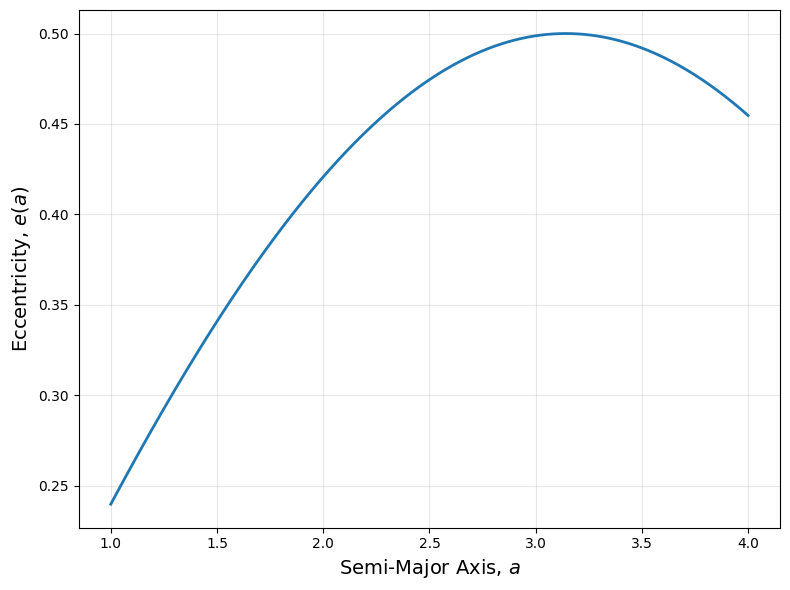

In [6]:
custom.plot()

Some useful keyword arguments include:

**Plot appearance:**

- `color`: Line colour (e.g. `'k'`, `'C1'`, `'#FF0000'`)
- `linestyle`: `'-'`, `'--'`, `':'`, etc.
- `linewidth` or `lw`: Line width
- `marker`: Marker style (`'o'`, `'.'`, `'s'`, etc.)
- `alpha`: Line transparency
- `label`: Legend label

**Axes and layout:**

- `xlim`, `ylim`: Axis ranges
- `xlabel`, `ylabel`, `title`: Override axis labels and title
- `grid`: Show/hide grid
- `log`: If `True`, use log scale for y-axis
- `save=True, filename="..."`: Save figure instead of displaying

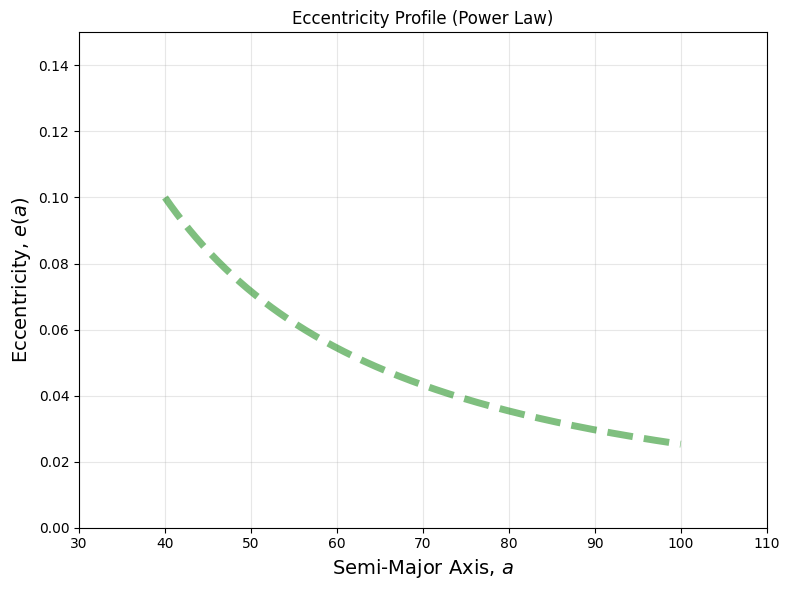

In [7]:
ecc = UniqueEccentricity(a_min=40, a_max=100, e0=0.1, power=1.5)

ecc.plot(
    color='green',
    linestyle='--',
    linewidth=5,
    alpha=0.5,
    xlim=(30, 110),
    ylim=(0, 0.15),
    title='Eccentricity Profile (Power Law)',
    grid=True
)